# 03 — HNSW Benchmarks

We sweep:

* `M` — number of edges per node (memory & build cost driver)
* `efConstruction` — build-time candidate width
* `efSearch` — query-time candidate width (recall ↔ QPS tunable)

Two studies:
1. Vary `M` (efConstruction fixed) → effect of graph degree
2. Vary `efConstruction` (M fixed) → effect of build quality
3. Heatmap `M × efSearch` → Recall@100

Notebook uses the same `data/imagenet1m.h5` + `BASE_PATH` memmap as notebook 02.

In [1]:
import os, sys, time, gc, json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import h5py
import faiss
import psutil
from tqdm import tqdm

sys.path.insert(0, str(Path.cwd()))
import utils

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 110

DATA = Path('data')
LAB_LIGHT = int(os.environ.get('LAB_LIGHT', '0'))
OUT_RUN = utils.run_mode()
RESULTS = utils.results_dir()
DOCS_IMG = utils.plots_dir()
print(f'OUT_RUN={OUT_RUN}  RESULTS={RESULTS}  DOCS_IMG={DOCS_IMG}')

# Load query + GT
with h5py.File(DATA / 'imagenet1m.h5', 'r') as h:
    queries = np.array(h['query'], dtype=np.float32)
    gt = np.array(h['groundtruth'], dtype=np.int32)
    DIM = int(h.attrs['dim']); N_BASE = int(h.attrs['n_base'])
    BASE_PATH = str(h.attrs['base_path'])

# Make BASE_PATH portable: prefer the file as it currently exists on disk
# (host path stored in h5 may not match container/CI paths).
_local = DATA / 'imagenet_base.fvecs'
if not Path(BASE_PATH).exists() and _local.exists():
    BASE_PATH = str(_local.resolve())
print('BASE_PATH =', BASE_PATH)

print('queries', queries.shape, 'gt', gt.shape, 'dim', DIM, 'base', N_BASE)
print(f"threads={faiss.omp_get_max_threads()}  RAM free={psutil.virtual_memory().available/1e9:.1f} GB")

OUT_RUN=full  RESULTS=results/full  DOCS_IMG=docs/img/full


BASE_PATH = data/imagenet_base.fvecs
queries (25000, 2048) gt (25000, 100) dim 2048 base 1281167
threads=8  RAM free=29.4 GB


In [2]:
N_SWEEP = int(os.environ.get('LAB_N_SWEEP', 500_000))
LAB_LIGHT = int(os.environ.get('LAB_LIGHT', '0'))

# Study 1: vary M, fixed ef_construction
M_GRID = [8, 16, 32, 48]
EFC_FIXED = 200
EFS_GRID = [10, 20, 40, 80, 160, 320, 640]
# Study 2: vary ef_construction, fixed M
M_FIXED = 32
EFC_GRID = [40, 100, 200, 400]

QUERY_K = 100
if LAB_LIGHT:
    M_GRID = [8, 16, 32]
    EFS_GRID = [10, 20, 40, 80, 160, 320]
    EFC_GRID = [40, 100, 200]
QPS_REPEAT = int(os.environ.get('LAB_QPS_REPEAT', '2' if LAB_LIGHT else '1'))
QPS_WARMUP = int(os.environ.get('LAB_QPS_WARMUP', '1' if LAB_LIGHT else '0'))
_default_qn = queries.shape[0] if LAB_LIGHT else min(10000, queries.shape[0])
QUERY_N = int(os.environ.get('LAB_QUERY_N', str(_default_qn)))
queries_sweep = queries[:QUERY_N]
print(f"N_SWEEP={N_SWEEP:,}  LAB_LIGHT={LAB_LIGHT}  M_GRID={M_GRID}  EFC_FIXED={EFC_FIXED}  EFS_GRID={EFS_GRID}")
print(f"M_FIXED={M_FIXED}  EFC_GRID={EFC_GRID}")
print(f"QPS_REPEAT={QPS_REPEAT}  QPS_WARMUP={QPS_WARMUP}  QUERY_N={QUERY_N}")

N_SWEEP=500,000  LAB_LIGHT=0  M_GRID=[8, 16, 32, 48]  EFC_FIXED=200  EFS_GRID=[10, 20, 40, 80, 160, 320, 640]
M_FIXED=32  EFC_GRID=[40, 100, 200, 400]
QPS_REPEAT=3  QPS_WARMUP=1  QUERY_N=10000


In [3]:
def ensure_gt(n: int, k: int = QUERY_K):
    cache = DATA / f'gt_n{n}_k{k}.npy'
    if cache.exists():
        return np.load(cache)
    print(f'Computing exact GT (Flat) on first {n:,} base vectors × {queries.shape[0]:,} queries × k={k}...')
    flat = faiss.IndexFlatL2(DIM)
    utils.stream_add(flat, BASE_PATH, n)
    _, I = flat.search(queries, k)
    np.save(cache, I)
    del flat; gc.collect()
    return I

gt_local = ensure_gt(N_SWEEP)
utils.print_mem('after GT')
print('gt_local', gt_local.shape, '  (base streamed from disk, not held in RAM)')

[mem after GT]  RSS=0.52 GB  ·  free=29.40 GB  ·  used%=10
gt_local (25000, 100)   (base streamed from disk, not held in RAM)


## Study 1 — vary M

Each `M` value runs in its own cell (CSV checkpoint).

In [4]:
HNSW_VARYM_PATH = RESULTS / 'hnsw_varyM.csv'
utils.init_results_csv(HNSW_VARYM_PATH)
print('HNSW vary-M checkpoint:', HNSW_VARYM_PATH)

HNSW vary-M checkpoint: results/full/hnsw_varyM.csv


#### HNSW study 1 — M=8

In [5]:
if 8 not in M_GRID:
    print('skip HNSW M=8')
else:
    rows = []
    idx = faiss.IndexHNSWFlat(DIM, 8, faiss.METRIC_L2)
    idx.hnsw.efConstruction = EFC_FIXED
    with utils.timed('build M=8', sample_rss_peak=True) as tb:
        utils.stream_add(idx, BASE_PATH, N_SWEEP)
    size_mb = utils.index_size_mb(idx)
    rss_mb = tb.rss_after_mb
    rss_peak_mb = tb.rss_peak_mb
    rss_delta_mb = tb.rss_delta_mb
    print(f'[M={8:3}]  build {tb.elapsed:7.1f}s · size {size_mb:7.1f} MB')
    for efs in EFS_GRID:
        idx.hnsw.efSearch = efs
        qps, lat_ms, lat_p99_ms, I = utils.measure_qps(
            lambda q,k: idx.search(q,k), queries_sweep, QUERY_K,
            repeat=QPS_REPEAT, warmup=QPS_WARMUP,
        )
        recalls = utils.compute_recalls(I, gt_local[:QUERY_N], (1, 10, 100))
        rows.append(dict(algo='HNSW', M=8, efConstruction=EFC_FIXED, efSearch=efs,
                        build_s=tb.elapsed, size_mb=size_mb, rss_mb=rss_mb, rss_peak_mb=rss_peak_mb,
                        rss_delta_mb=rss_delta_mb, **utils.bench_meta(),
                        qps=qps, latency_ms=lat_ms, latency_p99_ms=lat_p99_ms,
                        recall_1=recalls[1], recall_10=recalls[10], recall_100=recalls[100],
                        n_base=N_SWEEP, study='varyM'))
        print(f'    efS={efs:4}  qps={qps:8.1f}  R@100={recalls[100]:.3f}')
    del idx; gc.collect()
    utils.append_results(rows, HNSW_VARYM_PATH)

add (n=500,000, batch=50,000):   0%|                                                         | 0/10 [00:00<?, ?it/s]

add (n=500,000, batch=50,000):  10%|████▉                                            | 1/10 [00:03<00:27,  3.04s/it]

add (n=500,000, batch=50,000):  20%|█████████▊                                       | 2/10 [00:09<00:38,  4.79s/it]

add (n=500,000, batch=50,000):  30%|██████████████▋                                  | 3/10 [00:16<00:42,  6.14s/it]

add (n=500,000, batch=50,000):  40%|███████████████████▌                             | 4/10 [00:25<00:43,  7.20s/it]

...

    efS=  40  qps= 22492.1  R@100=0.836


    efS=  80  qps= 14686.3  R@100=0.934


    efS= 160  qps=  9150.4  R@100=0.975


    efS= 320  qps=  5547.5  R@100=0.990


    efS= 640  qps=  2923.0  R@100=0.996


#### HNSW study 1 — M=16

In [6]:
if 16 not in M_GRID:
    print('skip HNSW M=16')
else:
    rows = []
    idx = faiss.IndexHNSWFlat(DIM, 16, faiss.METRIC_L2)
    idx.hnsw.efConstruction = EFC_FIXED
    with utils.timed('build M=16', sample_rss_peak=True) as tb:
        utils.stream_add(idx, BASE_PATH, N_SWEEP)
    size_mb = utils.index_size_mb(idx)
    rss_mb = tb.rss_after_mb
    rss_peak_mb = tb.rss_peak_mb
    rss_delta_mb = tb.rss_delta_mb
    print(f'[M={16:3}]  build {tb.elapsed:7.1f}s · size {size_mb:7.1f} MB')
    for efs in EFS_GRID:
        idx.hnsw.efSearch = efs
        qps, lat_ms, lat_p99_ms, I = utils.measure_qps(
            lambda q,k: idx.search(q,k), queries_sweep, QUERY_K,
            repeat=QPS_REPEAT, warmup=QPS_WARMUP,
        )
        recalls = utils.compute_recalls(I, gt_local[:QUERY_N], (1, 10, 100))
        rows.append(dict(algo='HNSW', M=16, efConstruction=EFC_FIXED, efSearch=efs,
                        build_s=tb.elapsed, size_mb=size_mb, rss_mb=rss_mb, rss_peak_mb=rss_peak_mb,
                        rss_delta_mb=rss_delta_mb, **utils.bench_meta(),
                        qps=qps, latency_ms=lat_ms, latency_p99_ms=lat_p99_ms,
                        recall_1=recalls[1], recall_10=recalls[10], recall_100=recalls[100],
                        n_base=N_SWEEP, study='varyM'))
        print(f'    efS={efs:4}  qps={qps:8.1f}  R@100={recalls[100]:.3f}')
    del idx; gc.collect()
    utils.append_results(rows, HNSW_VARYM_PATH)

add (n=500,000, batch=50,000):   0%|                                                         | 0/10 [00:00<?, ?it/s]

add (n=500,000, batch=50,000):  10%|████▉                                            | 1/10 [00:03<00:30,  3.38s/it]

add (n=500,000, batch=50,000):  20%|█████████▊                                       | 2/10 [00:10<00:45,  5.69s/it]

add (n=500,000, batch=50,000):  30%|██████████████▋                                  | 3/10 [00:20<00:52,  7.46s/it]

add (n=500,000, batch=50,000):  40%|███████████████████▌                             | 4/10 [00:31<00:53,  8.93s/it]

...

    efS=  40  qps= 16355.8  R@100=0.902


    efS=  80  qps= 10418.5  R@100=0.968


    efS= 160  qps=  6279.5  R@100=0.991


    efS= 320  qps=  3919.2  R@100=0.998


    efS= 640  qps=  2040.0  R@100=0.999


#### HNSW study 1 — M=32

In [7]:
if 32 not in M_GRID:
    print('skip HNSW M=32')
else:
    rows = []
    idx = faiss.IndexHNSWFlat(DIM, 32, faiss.METRIC_L2)
    idx.hnsw.efConstruction = EFC_FIXED
    with utils.timed('build M=32', sample_rss_peak=True) as tb:
        utils.stream_add(idx, BASE_PATH, N_SWEEP)
    size_mb = utils.index_size_mb(idx)
    rss_mb = tb.rss_after_mb
    rss_peak_mb = tb.rss_peak_mb
    rss_delta_mb = tb.rss_delta_mb
    print(f'[M={32:3}]  build {tb.elapsed:7.1f}s · size {size_mb:7.1f} MB')
    for efs in EFS_GRID:
        idx.hnsw.efSearch = efs
        qps, lat_ms, lat_p99_ms, I = utils.measure_qps(
            lambda q,k: idx.search(q,k), queries_sweep, QUERY_K,
            repeat=QPS_REPEAT, warmup=QPS_WARMUP,
        )
        recalls = utils.compute_recalls(I, gt_local[:QUERY_N], (1, 10, 100))
        rows.append(dict(algo='HNSW', M=32, efConstruction=EFC_FIXED, efSearch=efs,
                        build_s=tb.elapsed, size_mb=size_mb, rss_mb=rss_mb, rss_peak_mb=rss_peak_mb,
                        rss_delta_mb=rss_delta_mb, **utils.bench_meta(),
                        qps=qps, latency_ms=lat_ms, latency_p99_ms=lat_p99_ms,
                        recall_1=recalls[1], recall_10=recalls[10], recall_100=recalls[100],
                        n_base=N_SWEEP, study='varyM'))
        print(f'    efS={efs:4}  qps={qps:8.1f}  R@100={recalls[100]:.3f}')
    del idx; gc.collect()
    utils.append_results(rows, HNSW_VARYM_PATH)

add (n=500,000, batch=50,000):   0%|                                                         | 0/10 [00:00<?, ?it/s]

add (n=500,000, batch=50,000):  10%|████▉                                            | 1/10 [00:03<00:31,  3.54s/it]

add (n=500,000, batch=50,000):  20%|█████████▊                                       | 2/10 [00:11<00:49,  6.13s/it]

add (n=500,000, batch=50,000):  30%|██████████████▋                                  | 3/10 [00:22<00:57,  8.17s/it]

add (n=500,000, batch=50,000):  40%|███████████████████▌                             | 4/10 [00:34<00:59,  9.89s/it]

...

    efS=  40  qps= 13633.2  R@100=0.925


    efS=  80  qps=  8571.1  R@100=0.979


    efS= 160  qps=  5104.3  R@100=0.995


    efS= 320  qps=  2999.1  R@100=0.999


    efS= 640  qps=  1642.0  R@100=1.000


#### HNSW study 1 — M=48

In [8]:
if 48 not in M_GRID:
    print('skip HNSW M=48')
else:
    rows = []
    idx = faiss.IndexHNSWFlat(DIM, 48, faiss.METRIC_L2)
    idx.hnsw.efConstruction = EFC_FIXED
    with utils.timed('build M=48', sample_rss_peak=True) as tb:
        utils.stream_add(idx, BASE_PATH, N_SWEEP)
    size_mb = utils.index_size_mb(idx)
    rss_mb = tb.rss_after_mb
    rss_peak_mb = tb.rss_peak_mb
    rss_delta_mb = tb.rss_delta_mb
    print(f'[M={48:3}]  build {tb.elapsed:7.1f}s · size {size_mb:7.1f} MB')
    for efs in EFS_GRID:
        idx.hnsw.efSearch = efs
        qps, lat_ms, lat_p99_ms, I = utils.measure_qps(
            lambda q,k: idx.search(q,k), queries_sweep, QUERY_K,
            repeat=QPS_REPEAT, warmup=QPS_WARMUP,
        )
        recalls = utils.compute_recalls(I, gt_local[:QUERY_N], (1, 10, 100))
        rows.append(dict(algo='HNSW', M=48, efConstruction=EFC_FIXED, efSearch=efs,
                        build_s=tb.elapsed, size_mb=size_mb, rss_mb=rss_mb, rss_peak_mb=rss_peak_mb,
                        rss_delta_mb=rss_delta_mb, **utils.bench_meta(),
                        qps=qps, latency_ms=lat_ms, latency_p99_ms=lat_p99_ms,
                        recall_1=recalls[1], recall_10=recalls[10], recall_100=recalls[100],
                        n_base=N_SWEEP, study='varyM'))
        print(f'    efS={efs:4}  qps={qps:8.1f}  R@100={recalls[100]:.3f}')
    del idx; gc.collect()
    utils.append_results(rows, HNSW_VARYM_PATH)

add (n=500,000, batch=50,000):   0%|                                                         | 0/10 [00:00<?, ?it/s]

add (n=500,000, batch=50,000):  10%|████▉                                            | 1/10 [00:03<00:31,  3.49s/it]

add (n=500,000, batch=50,000):  20%|█████████▊                                       | 2/10 [00:11<00:48,  6.12s/it]

add (n=500,000, batch=50,000):  30%|██████████████▋                                  | 3/10 [00:22<00:57,  8.23s/it]

add (n=500,000, batch=50,000):  40%|███████████████████▌                             | 4/10 [00:34<01:00, 10.03s/it]

...

    efS=  40  qps= 12982.2  R@100=0.928


    efS=  80  qps=  8148.8  R@100=0.980


    efS= 160  qps=  4846.2  R@100=0.995


    efS= 320  qps=  2715.2  R@100=0.999


    efS= 640  qps=  1645.4  R@100=1.000


In [9]:
df_M = pd.read_csv(HNSW_VARYM_PATH)
display(df_M.tail(8))

,algo,M,efConstruction,efSearch,build_s,size_mb,rss_mb,rss_peak_mb,rss_delta_mb,faiss_threads,qps,latency_ms,latency_p99_ms,recall_1,recall_10,recall_100,n_base,study
20,HNSW,32,200,640,127.364053,4036.012667,4594.226562,10902.503906,4033.972656,8,1642.018227,0.609607,1.140350,0.9995,0.99987,0.999733,500000,varyM
21,HNSW,48,200,10,130.322263,4097.019564,4655.082031,10992.089844,4094.796875,8,28003.181217,0.035676,0.055506,0.9367,0.89612,0.641150,500000,varyM
22,HNSW,48,200,20,130.322263,4097.019564,4655.082031,10992.089844,4094.796875,8,19532.032311,0.051312,0.082267,0.9760,0.95880,0.805800,500000,varyM
23,HNSW,48,200,40,130.322263,4097.019564,4655.082031,10992.089844,4094.796875,8,12982.242805,0.077108,0.132192,0.9912,0.98523,0.927775,500000,varyM
24,HNSW,48,200,80,130.322263,4097.019564,4655.082031,10992.089844,4094.796875,8,8148.751575,0.122760,0.220013,0.9970,0.99521,0.980112,500000,varyM
25,HNSW,48,200,160,130.322263,4097.019564,4655.082031,10992.089844,4094.796875,8,4846.219355,0.206358,0.385856,0.9989,0.99850,0.994885,500000,varyM
26,HNSW,48,200,320,130.322263,4097.019564,4655.082031,10992.089844,4094.796875,8,2715.243242,0.368318,0.694841,0.9993,0.99940,0.998629,500000,varyM
27,HNSW,48,200,640,130.322263,4097.019564,4655.082031,10992.089844,4094.796875,8,1645.381272,0.607128,1.199951,0.9996,0.99970,0.999580,500000,varyM


### Plot 1 — efSearch vs Recall@100 (per M)

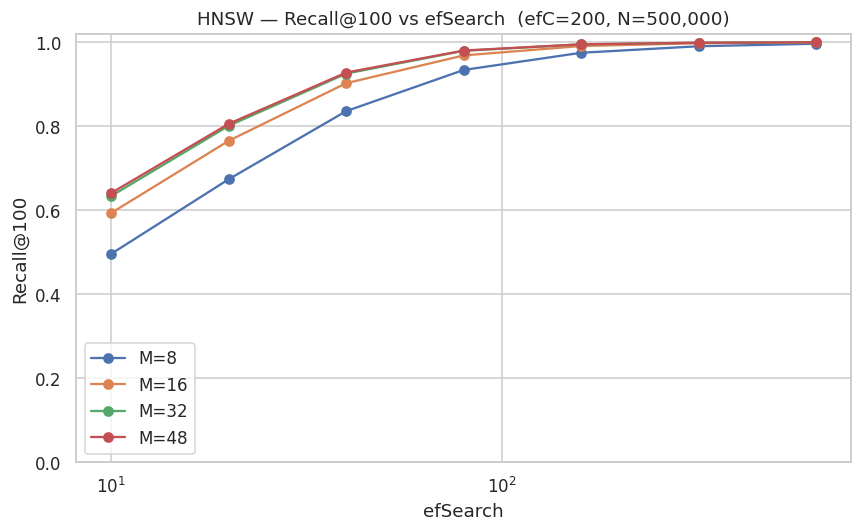

In [10]:
fig, ax = plt.subplots(figsize=(8, 5))
for M, sub in df_M.groupby('M'):
    sub = sub.sort_values('efSearch')
    ax.plot(sub.efSearch, sub.recall_100, marker='o', label=f'M={M}')
ax.set_xscale('log'); ax.set_xlabel('efSearch'); ax.set_ylabel('Recall@100')
ax.set_title(f'HNSW — Recall@100 vs efSearch  (efC={EFC_FIXED}, N={N_SWEEP:,})')
ax.legend(); ax.set_ylim(0, 1.02)
plt.tight_layout(); plt.savefig(DOCS_IMG / '03_hnsw_recall_vs_efs.png', dpi=120); plt.show()

### Plot 2 — QPS vs Recall@100 Pareto (per M)

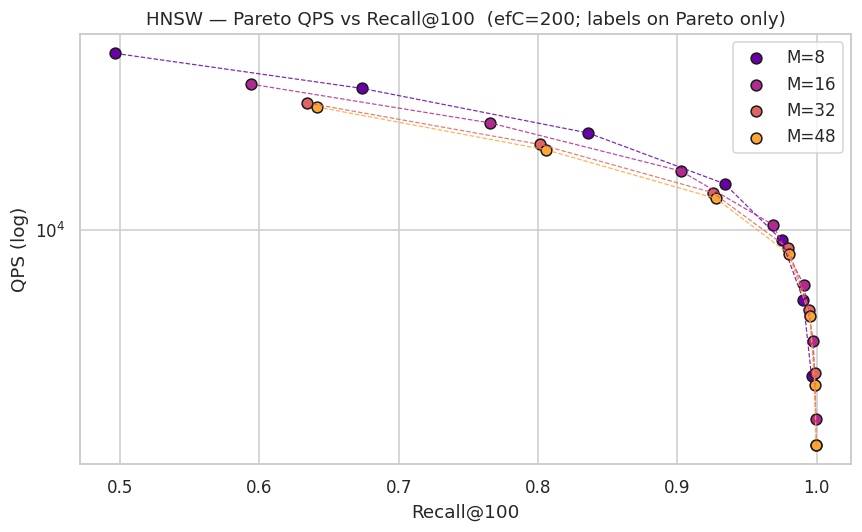

In [11]:
fig, ax = plt.subplots(figsize=(8, 5))
palette = sns.color_palette('plasma', len(M_GRID))
for col, (M, sub) in zip(palette, df_M.groupby('M')):
    ax.scatter(sub.recall_100, sub.qps, color=col, label=f'M={M}', s=50, edgecolors='k')
    ms = utils.pareto_frontier(sub.recall_100.values, sub.qps.values)
    o = np.argsort(sub.recall_100.values[ms])
    ax.plot(sub.recall_100.values[ms][o], sub.qps.values[ms][o], color=col, lw=0.8, ls='--', alpha=0.85)
    pidx = np.where(ms)[0]
    if len(pidx) <= 6:
        for i in pidx:
            r = sub.iloc[i]
            ax.annotate(f"efS={int(r.efSearch)}", (r.recall_100, r.qps), fontsize=6, alpha=0.75,
                        xytext=(3, 3), textcoords='offset points')
ax.set_yscale('log'); ax.set_xlabel('Recall@100'); ax.set_ylabel('QPS (log)')
ax.set_title('HNSW — Pareto QPS vs Recall@100  (efC={}; labels on Pareto only)'.format(EFC_FIXED))
ax.legend()
plt.tight_layout(); plt.savefig(DOCS_IMG / '03_hnsw_pareto_M.png', dpi=120); plt.show()

### Plot 3 & 4 — Build time / index size vs M

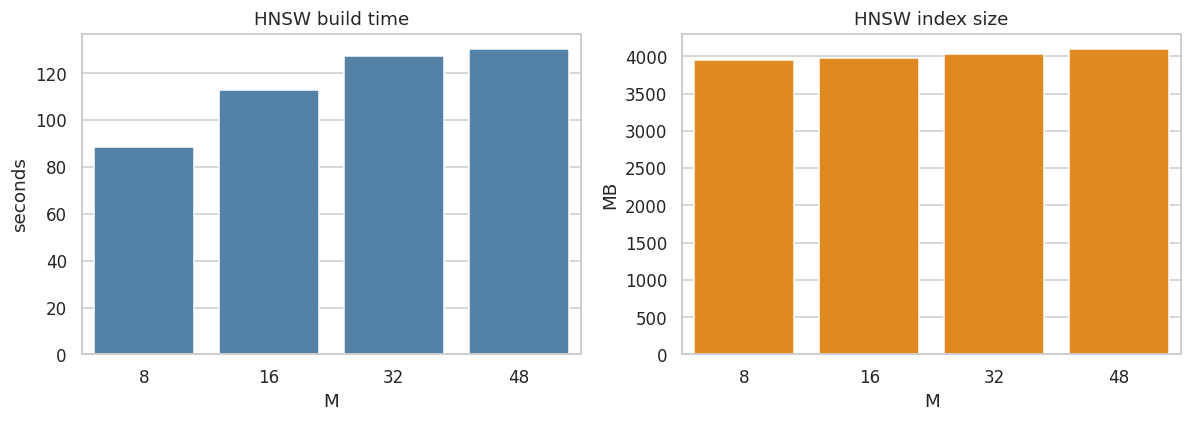

,M,build_s,size_mb
0,8,88.633670,3944.671679
1,16,112.846378,3975.048578
2,32,127.364053,4036.012667
3,48,130.322263,4097.019564


In [12]:
df_bt = df_M.drop_duplicates('M')[['M', 'build_s', 'size_mb']]
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
sns.barplot(data=df_bt, x='M', y='build_s', ax=ax[0], color='steelblue')
ax[0].set_title('HNSW build time'); ax[0].set_ylabel('seconds')
sns.barplot(data=df_bt, x='M', y='size_mb', ax=ax[1], color='darkorange')
ax[1].set_title('HNSW index size'); ax[1].set_ylabel('MB')
plt.tight_layout(); plt.savefig(DOCS_IMG / '03_hnsw_build_size_M.png', dpi=120); plt.show()
display(df_bt.reset_index(drop=True))

## Study 2 — vary efConstruction (M=32)

Each `efConstruction` value runs in its own cell (CSV checkpoint).

In [13]:
HNSW_VARYEFC_PATH = RESULTS / 'hnsw_varyEFC.csv'
utils.init_results_csv(HNSW_VARYEFC_PATH)
print('HNSW vary-efC checkpoint:', HNSW_VARYEFC_PATH)

HNSW vary-efC checkpoint: results/full/hnsw_varyEFC.csv


#### HNSW study 2 — efConstruction=40

In [14]:
if 40 not in EFC_GRID:
    print('skip HNSW efC=40')
else:
    rows = []
    idx = faiss.IndexHNSWFlat(DIM, M_FIXED, faiss.METRIC_L2)
    idx.hnsw.efConstruction = 40
    with utils.timed('build efC=40', sample_rss_peak=True) as tb:
        utils.stream_add(idx, BASE_PATH, N_SWEEP)
    size_mb = utils.index_size_mb(idx)
    rss_mb = tb.rss_after_mb
    rss_peak_mb = tb.rss_peak_mb
    rss_delta_mb = tb.rss_delta_mb
    print(f'[efC={40:4}]  build {tb.elapsed:7.1f}s · size {size_mb:7.1f} MB')
    for efs in EFS_GRID:
        idx.hnsw.efSearch = efs
        qps, lat_ms, lat_p99_ms, I = utils.measure_qps(
            lambda q,k: idx.search(q,k), queries_sweep, QUERY_K,
            repeat=QPS_REPEAT, warmup=QPS_WARMUP,
        )
        recalls = utils.compute_recalls(I, gt_local[:QUERY_N], (1, 10, 100))
        rows.append(dict(algo='HNSW', M=M_FIXED, efConstruction=40, efSearch=efs,
                        build_s=tb.elapsed, size_mb=size_mb, rss_mb=rss_mb, rss_peak_mb=rss_peak_mb,
                        rss_delta_mb=rss_delta_mb, **utils.bench_meta(),
                        qps=qps, latency_ms=lat_ms, latency_p99_ms=lat_p99_ms,
                        recall_1=recalls[1], recall_10=recalls[10], recall_100=recalls[100],
                        n_base=N_SWEEP, study='varyEFC'))
        print(f'    efS={efs:4}  qps={qps:8.1f}  R@100={recalls[100]:.3f}')
    del idx; gc.collect()
    utils.append_results(rows, HNSW_VARYEFC_PATH)

add (n=500,000, batch=50,000):   0%|                                                         | 0/10 [00:00<?, ?it/s]

add (n=500,000, batch=50,000):  10%|████▉                                            | 1/10 [00:01<00:16,  1.85s/it]

add (n=500,000, batch=50,000):  20%|█████████▊                                       | 2/10 [00:05<00:22,  2.77s/it]

add (n=500,000, batch=50,000):  30%|██████████████▋                                  | 3/10 [00:09<00:24,  3.43s/it]

add (n=500,000, batch=50,000):  40%|███████████████████▌                             | 4/10 [00:14<00:23,  4.00s/it]

...

    efS=  40  qps= 10937.7  R@100=0.949


    efS=  80  qps=  6998.5  R@100=0.982


    efS= 160  qps=  4203.7  R@100=0.994


    efS= 320  qps=  2442.8  R@100=0.998


    efS= 640  qps=  1338.8  R@100=1.000


#### HNSW study 2 — efConstruction=100

In [15]:
if 100 not in EFC_GRID:
    print('skip HNSW efC=100')
else:
    rows = []
    idx = faiss.IndexHNSWFlat(DIM, M_FIXED, faiss.METRIC_L2)
    idx.hnsw.efConstruction = 100
    with utils.timed('build efC=100', sample_rss_peak=True) as tb:
        utils.stream_add(idx, BASE_PATH, N_SWEEP)
    size_mb = utils.index_size_mb(idx)
    rss_mb = tb.rss_after_mb
    rss_peak_mb = tb.rss_peak_mb
    rss_delta_mb = tb.rss_delta_mb
    print(f'[efC={100:4}]  build {tb.elapsed:7.1f}s · size {size_mb:7.1f} MB')
    for efs in EFS_GRID:
        idx.hnsw.efSearch = efs
        qps, lat_ms, lat_p99_ms, I = utils.measure_qps(
            lambda q,k: idx.search(q,k), queries_sweep, QUERY_K,
            repeat=QPS_REPEAT, warmup=QPS_WARMUP,
        )
        recalls = utils.compute_recalls(I, gt_local[:QUERY_N], (1, 10, 100))
        rows.append(dict(algo='HNSW', M=M_FIXED, efConstruction=100, efSearch=efs,
                        build_s=tb.elapsed, size_mb=size_mb, rss_mb=rss_mb, rss_peak_mb=rss_peak_mb,
                        rss_delta_mb=rss_delta_mb, **utils.bench_meta(),
                        qps=qps, latency_ms=lat_ms, latency_p99_ms=lat_p99_ms,
                        recall_1=recalls[1], recall_10=recalls[10], recall_100=recalls[100],
                        n_base=N_SWEEP, study='varyEFC'))
        print(f'    efS={efs:4}  qps={qps:8.1f}  R@100={recalls[100]:.3f}')
    del idx; gc.collect()
    utils.append_results(rows, HNSW_VARYEFC_PATH)

add (n=500,000, batch=50,000):   0%|                                                         | 0/10 [00:00<?, ?it/s]

add (n=500,000, batch=50,000):  10%|████▉                                            | 1/10 [00:02<00:18,  2.10s/it]

add (n=500,000, batch=50,000):  20%|█████████▊                                       | 2/10 [00:06<00:26,  3.33s/it]

add (n=500,000, batch=50,000):  30%|██████████████▋                                  | 3/10 [00:11<00:30,  4.29s/it]

add (n=500,000, batch=50,000):  40%|███████████████████▌                             | 4/10 [00:18<00:30,  5.09s/it]

...

    efS=  40  qps= 15282.5  R@100=0.910


    efS=  80  qps=  9765.4  R@100=0.971


    efS= 160  qps=  5920.6  R@100=0.991


    efS= 320  qps=  3487.8  R@100=0.997


    efS= 640  qps=  1938.5  R@100=0.999


#### HNSW study 2 — efConstruction=200

In [16]:
if 200 not in EFC_GRID:
    print('skip HNSW efC=200')
else:
    rows = []
    idx = faiss.IndexHNSWFlat(DIM, M_FIXED, faiss.METRIC_L2)
    idx.hnsw.efConstruction = 200
    with utils.timed('build efC=200', sample_rss_peak=True) as tb:
        utils.stream_add(idx, BASE_PATH, N_SWEEP)
    size_mb = utils.index_size_mb(idx)
    rss_mb = tb.rss_after_mb
    rss_peak_mb = tb.rss_peak_mb
    rss_delta_mb = tb.rss_delta_mb
    print(f'[efC={200:4}]  build {tb.elapsed:7.1f}s · size {size_mb:7.1f} MB')
    for efs in EFS_GRID:
        idx.hnsw.efSearch = efs
        qps, lat_ms, lat_p99_ms, I = utils.measure_qps(
            lambda q,k: idx.search(q,k), queries_sweep, QUERY_K,
            repeat=QPS_REPEAT, warmup=QPS_WARMUP,
        )
        recalls = utils.compute_recalls(I, gt_local[:QUERY_N], (1, 10, 100))
        rows.append(dict(algo='HNSW', M=M_FIXED, efConstruction=200, efSearch=efs,
                        build_s=tb.elapsed, size_mb=size_mb, rss_mb=rss_mb, rss_peak_mb=rss_peak_mb,
                        rss_delta_mb=rss_delta_mb, **utils.bench_meta(),
                        qps=qps, latency_ms=lat_ms, latency_p99_ms=lat_p99_ms,
                        recall_1=recalls[1], recall_10=recalls[10], recall_100=recalls[100],
                        n_base=N_SWEEP, study='varyEFC'))
        print(f'    efS={efs:4}  qps={qps:8.1f}  R@100={recalls[100]:.3f}')
    del idx; gc.collect()
    utils.append_results(rows, HNSW_VARYEFC_PATH)

add (n=500,000, batch=50,000):   0%|                                                         | 0/10 [00:00<?, ?it/s]

add (n=500,000, batch=50,000):  10%|████▉                                            | 1/10 [00:03<00:31,  3.51s/it]

add (n=500,000, batch=50,000):  20%|█████████▊                                       | 2/10 [00:11<00:49,  6.13s/it]

add (n=500,000, batch=50,000):  30%|██████████████▋                                  | 3/10 [00:22<00:57,  8.15s/it]

add (n=500,000, batch=50,000):  40%|███████████████████▌                             | 4/10 [00:34<00:59,  9.88s/it]

...

    efS=  40  qps= 13621.8  R@100=0.926


    efS=  80  qps=  8558.0  R@100=0.979


    efS= 160  qps=  5103.2  R@100=0.995


    efS= 320  qps=  3001.1  R@100=0.999


    efS= 640  qps=  1635.5  R@100=1.000


#### HNSW study 2 — efConstruction=400

In [17]:
if 400 not in EFC_GRID:
    print('skip HNSW efC=400')
else:
    rows = []
    idx = faiss.IndexHNSWFlat(DIM, M_FIXED, faiss.METRIC_L2)
    idx.hnsw.efConstruction = 400
    with utils.timed('build efC=400', sample_rss_peak=True) as tb:
        utils.stream_add(idx, BASE_PATH, N_SWEEP)
    size_mb = utils.index_size_mb(idx)
    rss_mb = tb.rss_after_mb
    rss_peak_mb = tb.rss_peak_mb
    rss_delta_mb = tb.rss_delta_mb
    print(f'[efC={400:4}]  build {tb.elapsed:7.1f}s · size {size_mb:7.1f} MB')
    for efs in EFS_GRID:
        idx.hnsw.efSearch = efs
        qps, lat_ms, lat_p99_ms, I = utils.measure_qps(
            lambda q,k: idx.search(q,k), queries_sweep, QUERY_K,
            repeat=QPS_REPEAT, warmup=QPS_WARMUP,
        )
        recalls = utils.compute_recalls(I, gt_local[:QUERY_N], (1, 10, 100))
        rows.append(dict(algo='HNSW', M=M_FIXED, efConstruction=400, efSearch=efs,
                        build_s=tb.elapsed, size_mb=size_mb, rss_mb=rss_mb, rss_peak_mb=rss_peak_mb,
                        rss_delta_mb=rss_delta_mb, **utils.bench_meta(),
                        qps=qps, latency_ms=lat_ms, latency_p99_ms=lat_p99_ms,
                        recall_1=recalls[1], recall_10=recalls[10], recall_100=recalls[100],
                        n_base=N_SWEEP, study='varyEFC'))
        print(f'    efS={efs:4}  qps={qps:8.1f}  R@100={recalls[100]:.3f}')
    del idx; gc.collect()
    utils.append_results(rows, HNSW_VARYEFC_PATH)

add (n=500,000, batch=50,000):   0%|                                                         | 0/10 [00:00<?, ?it/s]

add (n=500,000, batch=50,000):  10%|████▉                                            | 1/10 [00:06<00:55,  6.22s/it]

add (n=500,000, batch=50,000):  20%|█████████▊                                       | 2/10 [00:21<01:33, 11.70s/it]

add (n=500,000, batch=50,000):  30%|██████████████▋                                  | 3/10 [00:42<01:52, 16.05s/it]

add (n=500,000, batch=50,000):  40%|███████████████████▌                             | 4/10 [01:08<01:57, 19.61s/it]

...

    efS=  40  qps= 12324.3  R@100=0.933


    efS=  80  qps=  7654.0  R@100=0.984


    efS= 160  qps=  4495.2  R@100=0.997


    efS= 320  qps=  2623.2  R@100=0.999


    efS= 640  qps=  1435.1  R@100=1.000


In [18]:
df_EFC = pd.read_csv(HNSW_VARYEFC_PATH)
display(df_EFC.tail(8))

,algo,M,efConstruction,efSearch,build_s,size_mb,rss_mb,rss_peak_mb,rss_delta_mb,faiss_threads,qps,latency_ms,latency_p99_ms,recall_1,recall_10,recall_100,n_base,study
20,HNSW,32,200,640,127.344182,4036.012667,4601.085938,11025.363281,4033.316406,8,1635.548887,0.611047,1.151948,0.9995,0.99988,0.999740,500000,varyEFC
21,HNSW,32,400,10,252.119201,4036.012667,4599.093750,11162.671875,4034.667969,8,27009.382382,0.037022,0.057211,0.9425,0.90081,0.642887,500000,varyEFC
22,HNSW,32,400,20,252.119201,4036.012667,4599.093750,11162.671875,4034.667969,8,18745.825750,0.053324,0.085541,0.9802,0.96426,0.810533,500000,varyEFC
23,HNSW,32,400,40,252.119201,4036.012667,4599.093750,11162.671875,4034.667969,8,12324.301477,0.081221,0.139013,0.9932,0.98903,0.933021,500000,varyEFC
24,HNSW,32,400,80,252.119201,4036.012667,4599.093750,11162.671875,4034.667969,8,7653.958018,0.130616,0.232424,0.9984,0.99741,0.983900,500000,varyEFC
25,HNSW,32,400,160,252.119201,4036.012667,4599.093750,11162.671875,4034.667969,8,4495.233161,0.222309,0.406071,0.9992,0.99934,0.996629,500000,varyEFC
26,HNSW,32,400,320,252.119201,4036.012667,4599.093750,11162.671875,4034.667969,8,2623.225889,0.380924,0.705270,0.9995,0.99974,0.999325,500000,varyEFC
27,HNSW,32,400,640,252.119201,4036.012667,4599.093750,11162.671875,4034.667969,8,1435.146635,0.699071,1.299212,0.9998,0.99994,0.999887,500000,varyEFC


### Plot 5 — Recall@100 vs efSearch (per efConstruction, M fixed)

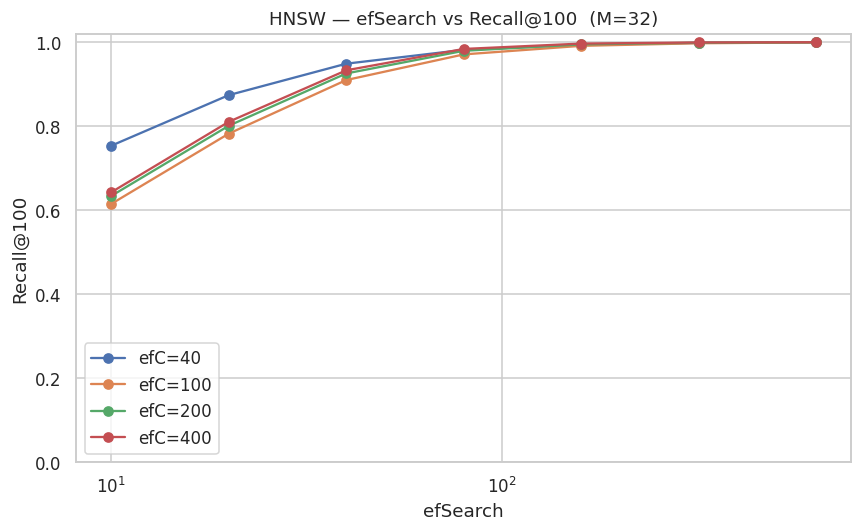

In [19]:
fig, ax = plt.subplots(figsize=(8, 5))
for efc, sub in df_EFC.groupby('efConstruction'):
    sub = sub.sort_values('efSearch')
    ax.plot(sub.efSearch, sub.recall_100, marker='o', label=f'efC={efc}')
ax.set_xscale('log'); ax.set_xlabel('efSearch'); ax.set_ylabel('Recall@100')
ax.set_title(f'HNSW — efSearch vs Recall@100  (M={M_FIXED})')
ax.legend(); ax.set_ylim(0, 1.02)
plt.tight_layout(); plt.savefig(DOCS_IMG / '03_hnsw_recall_vs_efs_EFC.png', dpi=120); plt.show()

### Plot 6 — Build time vs efConstruction

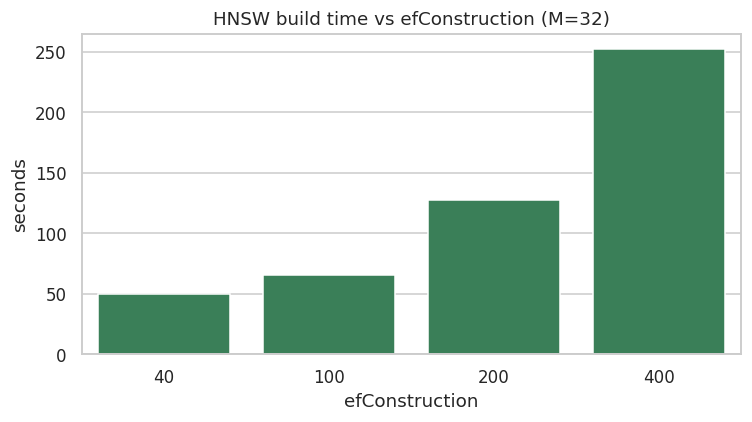

,efConstruction,build_s
0,40,49.778232
1,100,65.282220
2,200,127.344182
3,400,252.119201


In [20]:
df_bt2 = df_EFC.drop_duplicates('efConstruction')[['efConstruction', 'build_s']]
fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(data=df_bt2, x='efConstruction', y='build_s', ax=ax, color='seagreen')
ax.set_title(f'HNSW build time vs efConstruction (M={M_FIXED})')
ax.set_ylabel('seconds')
plt.tight_layout(); plt.savefig(DOCS_IMG / '03_hnsw_build_vs_EFC.png', dpi=120); plt.show()
display(df_bt2.reset_index(drop=True))

### Plot 7 — Heatmap M × efSearch → Recall@100

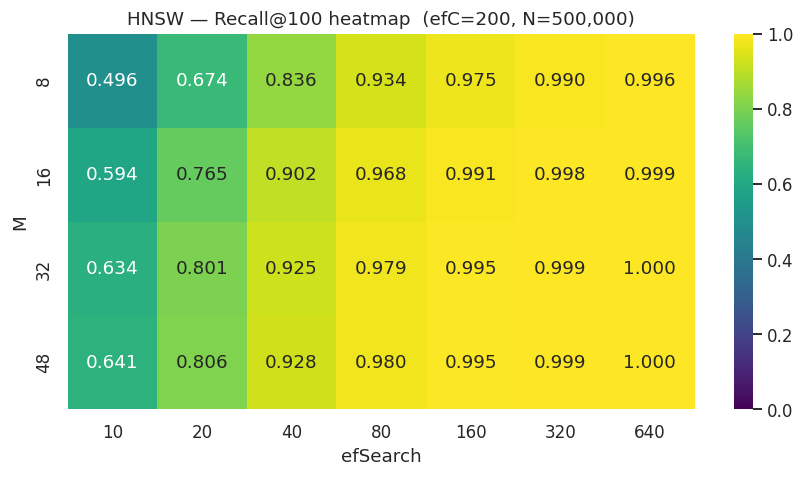

rows 56


In [21]:
piv = df_M.pivot(index='M', columns='efSearch', values='recall_100')
fig, ax = plt.subplots(figsize=(8, 4.5))
sns.heatmap(piv, annot=True, fmt='.3f', cmap='viridis', vmin=0, vmax=1, ax=ax)
ax.set_title(f'HNSW — Recall@100 heatmap  (efC={EFC_FIXED}, N={N_SWEEP:,})')
plt.tight_layout(); plt.savefig(DOCS_IMG / '03_hnsw_heatmap.png', dpi=120); plt.show()

# Combined CSV for notebook 05
df_all_hnsw = pd.concat([df_M, df_EFC], ignore_index=True)
df_all_hnsw.to_csv(RESULTS / 'hnsw_all.csv', index=False)
print('rows', len(df_all_hnsw))

## Summary

* Larger `M` → higher recall and bigger index, with diminishing return after M ≈ 32.
* Higher `efConstruction` mostly helps **at the top of the recall range**
  (`Recall@100 ≥ 0.9`).
* `efSearch` is a *runtime knob* — adjustable without rebuilding.

See `05_comparison.ipynb` for cross-algorithm comparison.